In [25]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

In [2]:
SUFFIX = "ckpt-200"
# CKPT_PATH = f"/exp_local/kenzosaki/models/ai_events_gemma_3_4b_clm_r128_lr1e-4_no_json/checkpoint-{SUFFIX.split('-')[1]}"
CKPT_PATH = f"/exp_local/kenzosaki/models/ai_events_gemma_3_4b_dpo/checkpoint-{SUFFIX.split('-')[1]}"
logs = pickle.load(open(f"{CKPT_PATH}/clm_experiment.pkl", "rb"))
logs_with_history = pickle.load(open(f"{CKPT_PATH}/event_history.pkl", "rb"))

In [3]:
logs.keys()

dict_keys(['test_perplexities', 'test_labels', 'sampled_edges_perplexities'])

# Analisando perplexidades para arestas isoladas

In [4]:
test_perplexities = logs["test_perplexities"]
test_labels = logs["test_labels"]
sampled_edges_perplexities = logs["sampled_edges_perplexities"]

all_perplexities = test_perplexities + sampled_edges_perplexities
all_labels = test_labels + ["true-positive"] * len(sampled_edges_perplexities)

Text(0.5, 1.0, 'Test Perplexities')

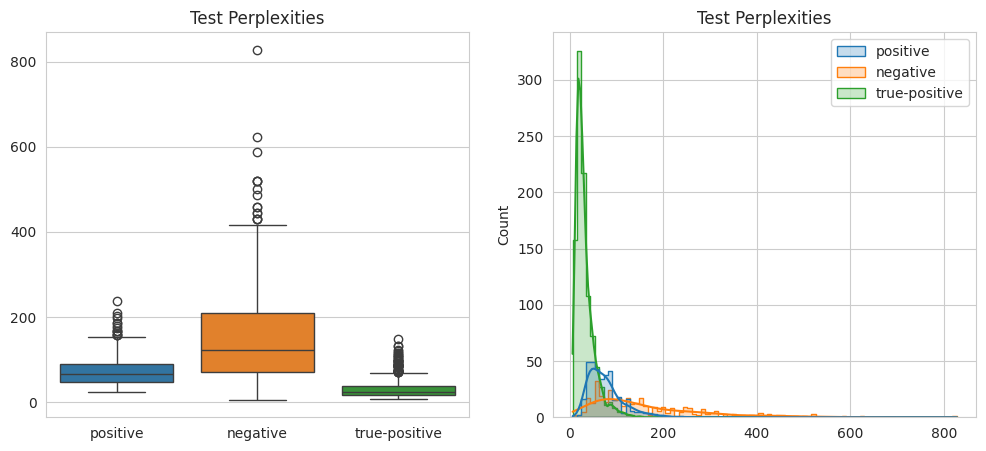

In [5]:
# visualizando perplexxidades e labels
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.set_style("whitegrid")
sns.boxplot(y=all_perplexities, hue=all_labels, x=all_labels)
plt.title("Test Perplexities")

plt.subplot(1, 2, 2)
sns.histplot(x=all_perplexities, hue=all_labels, kde=True, element="step")
plt.title("Test Perplexities")


In [6]:
perp_df = pd.DataFrame({
    "perplexity": all_perplexities,
    "label": all_labels
})

In [7]:
perp_df.groupby("label").describe()

perplexity                                                  \
                   count        mean         std     min      25%    50%   
label                                                                      
negative           356.0  157.197683  117.860701   5.625  70.0000  123.0   
positive           356.0   74.941362   36.345493  23.125  46.7500   66.0   
true-positive     1000.0   30.928687   19.827196   7.750  17.6875   25.0   

                             
                 75%    max  
label                        
negative       209.0  828.0  
positive        90.0  237.0  
true-positive   38.0  148.0

In [8]:
THRESHOLD = 100
test_df = perp_df[perp_df["label"] != "true-positive"]
sorted_ids = test_df.sort_values("perplexity", ascending=True).index
sample_df = test_df.loc[sorted_ids[:THRESHOLD]]
sample_df.value_counts("label", normalize=True)

label
positive    0.73
negative    0.27
Name: proportion, dtype: float64

In [33]:
PERPLEXITY_THRESHOLD = 80
preds = np.array(test_perplexities) < PERPLEXITY_THRESHOLD
preds = np.where(preds, "positive", "negative")
print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

    negative       0.67      0.71      0.69       356
    positive       0.69      0.65      0.67       356

    accuracy                           0.68       712
   macro avg       0.68      0.68      0.68       712
weighted avg       0.68      0.68      0.68       712



# Repetindo a analise para caminhadas

In [9]:
perp_history_df = pd.DataFrame({
    "perplexity": logs_with_history["test_perplexities_with_history"],
    "label": logs_with_history["labels"]
})

Text(0.5, 1.0, 'Test Perplexities')

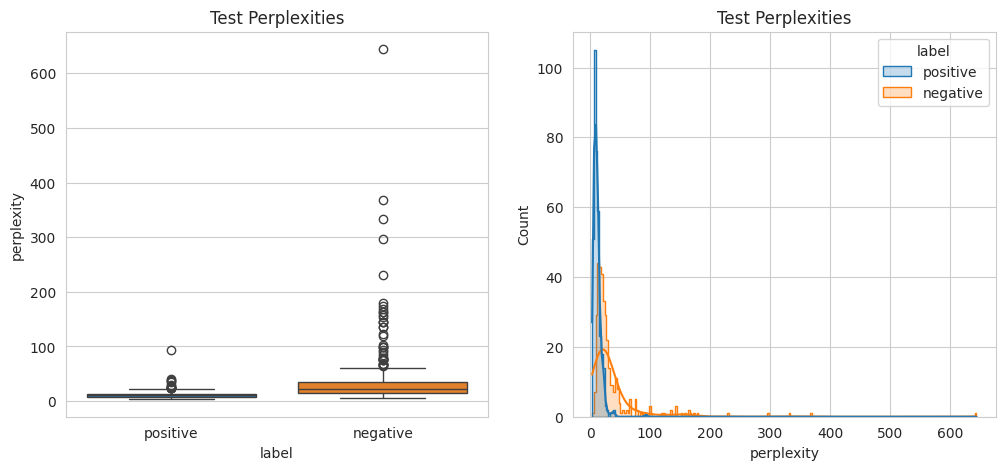

In [10]:
# visualizando perplexxidades e labels
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.set_style("whitegrid")
sns.boxplot(data=perp_history_df, y="perplexity", hue="label", x="label")
plt.title("Test Perplexities")

plt.subplot(1, 2, 2)
sns.histplot(data=perp_history_df, x="perplexity", hue="label", kde=True, element="step")
plt.title("Test Perplexities")


Text(0.5, 1.0, 'Test Perplexities')

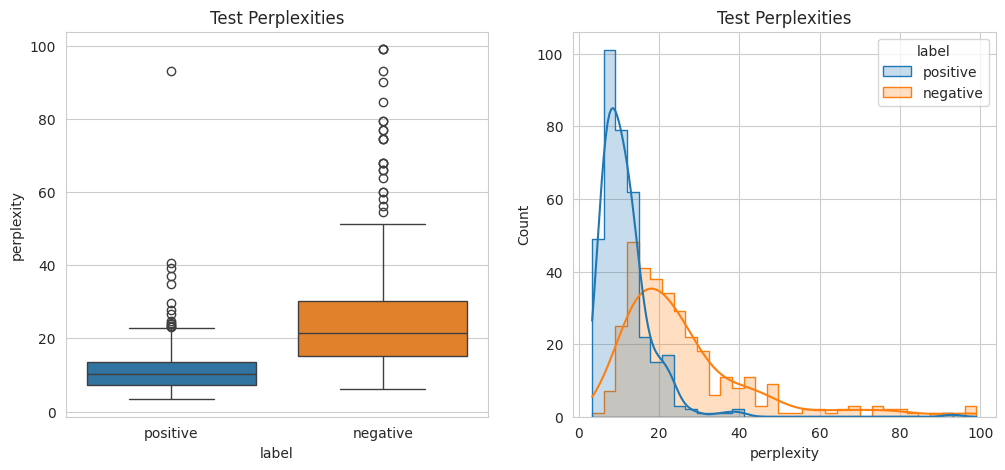

In [34]:
# visualizando perplexxidades e labels
mask = perp_history_df["perplexity"] < 100
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.set_style("whitegrid")
sns.boxplot(data=perp_history_df[mask], y="perplexity", hue="label", x="label")
plt.title("Test Perplexities")

plt.subplot(1, 2, 2)
sns.histplot(data=perp_history_df[mask], x="perplexity", hue="label", kde=True, element="step")
plt.title("Test Perplexities")


In [11]:
perp_history_df.groupby("label").describe()

perplexity                                                    \
              count       mean        std       min     25%       50%   
label                                                                   
negative      356.0  36.341292  52.861495  6.125000  15.625  22.37500   
positive      356.0  11.610209   7.100042  3.359375   7.375  10.34375   

                          
              75%    max  
label                     
negative  34.7500  644.0  
positive  13.5625   93.0

In [12]:
THRESHOLD = 100
sorted_ids = perp_history_df.sort_values("perplexity", ascending=True).index
sample_df = perp_history_df.loc[sorted_ids[:THRESHOLD]]
sample_df.value_counts("label", normalize=True)

label
positive    0.97
negative    0.03
Name: proportion, dtype: float64

In [29]:
PERPLEXITY_THRESHOLD = 15
preds = perp_history_df["perplexity"] < PERPLEXITY_THRESHOLD
preds = np.where(preds, "positive", "negative")
print(classification_report(perp_history_df["label"], preds))

              precision    recall  f1-score   support

    negative       0.81      0.77      0.79       356
    positive       0.78      0.82      0.80       356

    accuracy                           0.79       712
   macro avg       0.80      0.79      0.79       712
weighted avg       0.80      0.79      0.79       712



In [14]:
# TODO: hipotese para investigar: o quanto estas perrplexidades variam de acordo comm a quantidade de eventos anteriores.

# Visualizando losses

In [15]:
import numpy as np
import json

def show_losses(graph_df: pd.DataFrame, bs: int = 1024, title: str = "Losses", log_scale: bool = False) -> None:
    # filtrando valores de loss e eval_loss
    train_losses = graph_df['loss']
    loss_idx = ~train_losses.isna()
    train_losses = train_losses[loss_idx].tolist()
    train_steps = graph_df[loss_idx]['step'].tolist()
    val_losses = graph_df['eval_loss']
    loss_idx = ~val_losses.isna()
    val_losses = val_losses[loss_idx].tolist()
    val_steps = graph_df[loss_idx]['step'].tolist()

    all_losses = train_losses + val_losses

    if log_scale:
        all_losses = np.log(all_losses)

    iters = train_steps + val_steps
    iters = [i * bs for i in iters]  # multiplicando por bs para representar o numero de exemplos 

    labels = ["Train"] * len(train_losses) + ["Validation"] * len(val_losses) 
    plt.title(title)
    sns.lineplot(x=iters, y=all_losses, hue=labels, palette=["blue", "orange"])
    plt.show()



In [16]:
losses_logs = json.load(open(CKPT_PATH + "/trainer_state.json", "r"))
losses_df = pd.DataFrame(losses_logs['log_history'])

In [17]:
view_df = losses_df.loc[losses_df.index[-250:]]
#view_df = losses_df
show_losses(view_df,  bs=1, title="Training and Validation Losses", log_scale=False)

KeyError: 'eval_loss'

#